In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [ ]:
DATA_PATH = "advertising.csv"
TARGET_COL = "Sales"
TEST_SIZE = 0.2
RANDOM_SEED = 42

In [ ]:
df_raw = pd.read_csv(DATA_PATH)


In [ ]:
df_raw.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
df_zero = df_raw.fillna(0)

df_mean = df_raw.copy()
numeric_cols = df_mean.select_dtypes(include=['float64', 'int64']).columns
df_mean[numeric_cols] = df_mean[numeric_cols].fillna(df_mean[numeric_cols].mean())

df_median = df_raw.copy()
df_median[numeric_cols] = df_median[numeric_cols].fillna(df_median[numeric_cols].median())


In [ ]:
def customMinMaxScaler(df):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df_minmax = df.copy()
    for col in numeric_cols:
        min_val = df[col].min()
        max_val = df[col].max()
        if max_val != min_val:
            df_minmax[col] = (df[col] - min_val) / (max_val - min_val)
        else:
            df_minmax[col] = 0
    return df_minmax

In [ ]:
def customStandardScaler(df):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df_standard = df.copy()
    for col in numeric_cols:
        mean_val = df[col].mean()
        std_val = df[col].std()
        if std_val != 0:
            df_standard[col] = (df[col] - mean_val) / std_val
        else:
            df_standard[col] = 0
    return df_standard

In [ ]:
def detect_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    outlier_indices = set()
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_indices.update(df[(df[col] < lower_bound) | (df[col] > upper_bound)].index)
    return list(outlier_indices)

In [ ]:
def train_test_split_custom(X, y, test_size=0.2, random_seed=42):
    n = X.shape[0]
    indices = np.arange(n)
    rng = np.random.RandomState(random_seed)
    rng.shuffle(indices)
    split_idx = int(n * (1 - test_size))
    train_idx = indices[:split_idx]
    test_idx = indices[split_idx:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [ ]:
def r2_score_custom(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

In [ ]:
def mse_custom(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse_custom(y_true, y_pred):
    return np.sqrt(mse_custom(y_true, y_pred))

def mae_custom(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [ ]:
class SGDRegressorCustom:
    def __init__(self, learning_rate=0.001, epochs=50):
        self.coef_ = None
        self.intercept_ = 0.0
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X_train, y_train):
        n_samples, n_features = X_train.shape
        self.coef_ = np.zeros(n_features, dtype=float)
        self.intercept_ = 0.0

        for epoch in range(self.epochs):
            indices = np.random.permutation(n_samples)
            for idx in indices:
                x_i = X_train[idx]
                y_i = y_train[idx]
                y_hat = np.dot(x_i, self.coef_) + self.intercept_
                error = y_i - y_hat
                self.coef_ += self.lr * 2 * error * x_i
                self.intercept_ += self.lr * 2 * error
        return self

    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_


In [ ]:
def evaluate_dataset(df, name, target_col, remove_outliers=False):
    df_local = df.copy()
    df_local = df_local.dropna(subset=[target_col])
    if remove_outliers:
        out_idx = detect_outliers_iqr(df_local)
        df_local = df_local.drop(index=out_idx).reset_index(drop=True)

    X = df_local.drop(columns=[target_col])
    y = df_local[target_col].values.astype(float)

    X_numeric = X.select_dtypes(include=['float64', 'int64']).copy()
    if X_numeric.shape[1] == 0:
        raise ValueError(f"No numeric feature columns found for dataset {name}. Encode categorical features first.")

    X_arr = X_numeric.values.astype(float)

    X_train, X_test, y_train, y_test = train_test_split_custom(X_arr, y, test_size=TEST_SIZE, random_seed=RANDOM_SEED)

    model = SGDRegressorCustom(learning_rate=0.001, epochs=200)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "r2": r2_score_custom(y_test, y_pred),
        "mse": mse_custom(y_test, y_pred),
        "rmse": rmse_custom(y_test, y_pred),
        "mae": mae_custom(y_test, y_pred),
        "n_train": X_train.shape[0],
        "n_test": X_test.shape[0],
    }
    return metrics, X_numeric.columns.tolist()

In [ ]:
def run_all(df_zero, df_mean, df_median):
    datasets = {
        "zero_minmax": customMinMaxScaler(df_zero),
        "zero_standard": customStandardScaler(df_zero),
        "mean_minmax": customMinMaxScaler(df_mean),
        "mean_standard": customStandardScaler(df_mean),
        "median_minmax": customMinMaxScaler(df_median),
        "median_standard": customStandardScaler(df_median),
    }

    results = []
    for name, dset in datasets.items():
        try:
            metrics_with, feat_cols = evaluate_dataset(dset, name, TARGET_COL, remove_outliers=False)
        except Exception as e:
            print(f"Skipping {name} (error): {e}")
            continue

        try:
            metrics_wo, _ = evaluate_dataset(dset, name, TARGET_COL, remove_outliers=True)
        except Exception as e:
            print(f"Skipping {name} no-outliers (error): {e}")
            continue

        results.append({**metrics_with, "dataset": name, "with_outliers": True})
        results.append({**metrics_wo, "dataset": name, "with_outliers": False})

    return pd.DataFrame(results)

In [ ]:
def plot_metric(df_results, metric, title=None, savepath=None):
    pivot = df_results.pivot(index="dataset", columns="with_outliers", values=metric)
    pivot["mean"] = pivot.mean(axis=1)
    pivot = pivot.sort_values("mean", ascending=False).drop(columns=["mean"])
    ax = pivot.plot(kind="bar", figsize=(12, 6))
    ax.set_title(title or f"Comparison of {metric}")
    ax.set_xlabel("Dataset (missing-scaling combo)")
    ax.set_ylabel(metric)
    ax.legend(["with_outliers", "without_outliers"])
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath)
    plt.show()

Saved results_summary.csv
          r2       mse      rmse       mae  n_train  n_test          dataset  \
0   0.880543  0.005466  0.073934  0.052219      160      40      zero_minmax   
1   0.935054  0.003230  0.056835  0.043232      158      40      zero_minmax   
2   0.880653  0.126195  0.355239  0.249764      160      40    zero_standard   
3   0.936503  0.072977  0.270143  0.206457      158      40    zero_standard   
4   0.880434  0.005471  0.073967  0.052256      160      40      mean_minmax   
5   0.935046  0.003231  0.056838  0.043226      158      40      mean_minmax   
6   0.880636  0.126213  0.355265  0.249915      160      40    mean_standard   
7   0.936116  0.073422  0.270966  0.207257      158      40    mean_standard   
8   0.880581  0.005464  0.073922  0.052206      160      40    median_minmax   
9   0.935037  0.003231  0.056842  0.043184      158      40    median_minmax   
10  0.880631  0.126219  0.355273  0.249653      160      40  median_standard   
11  0.936433  

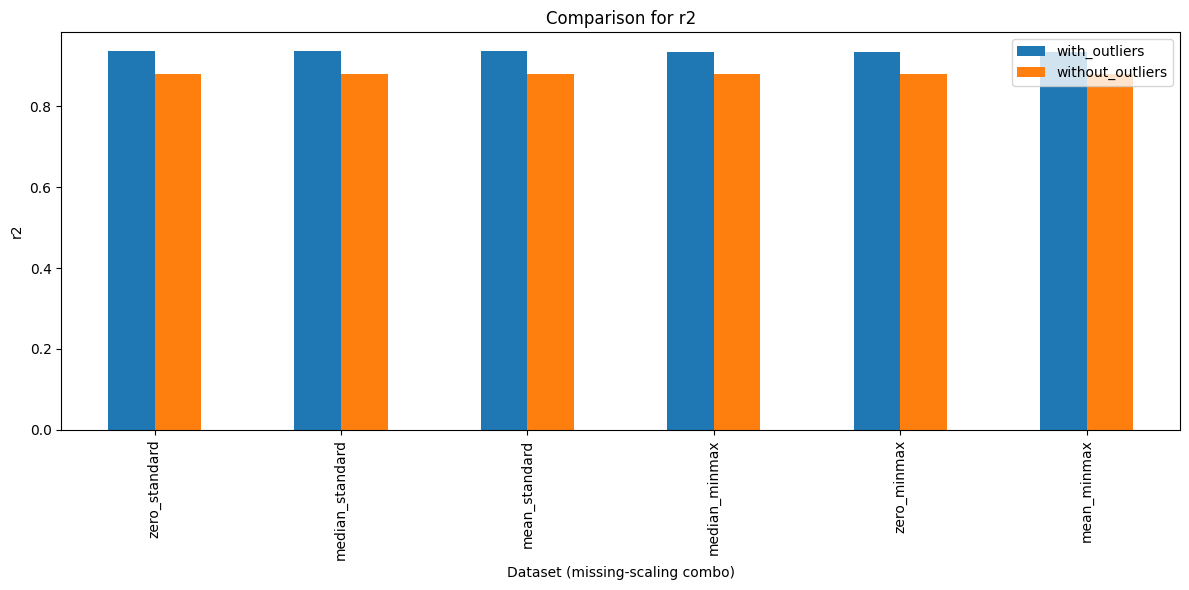

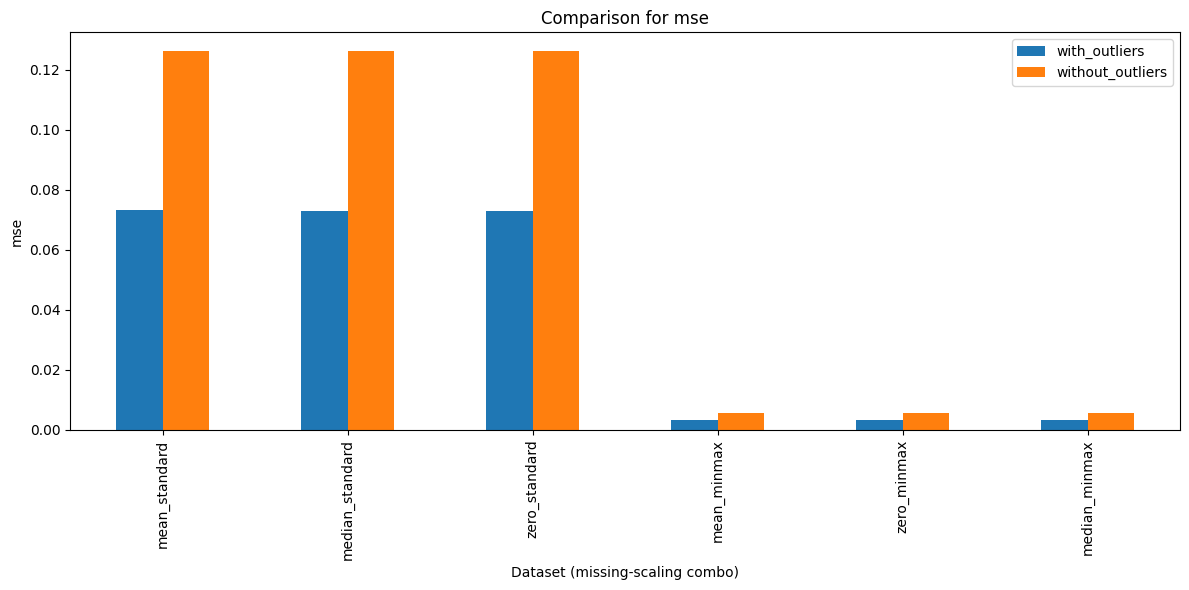

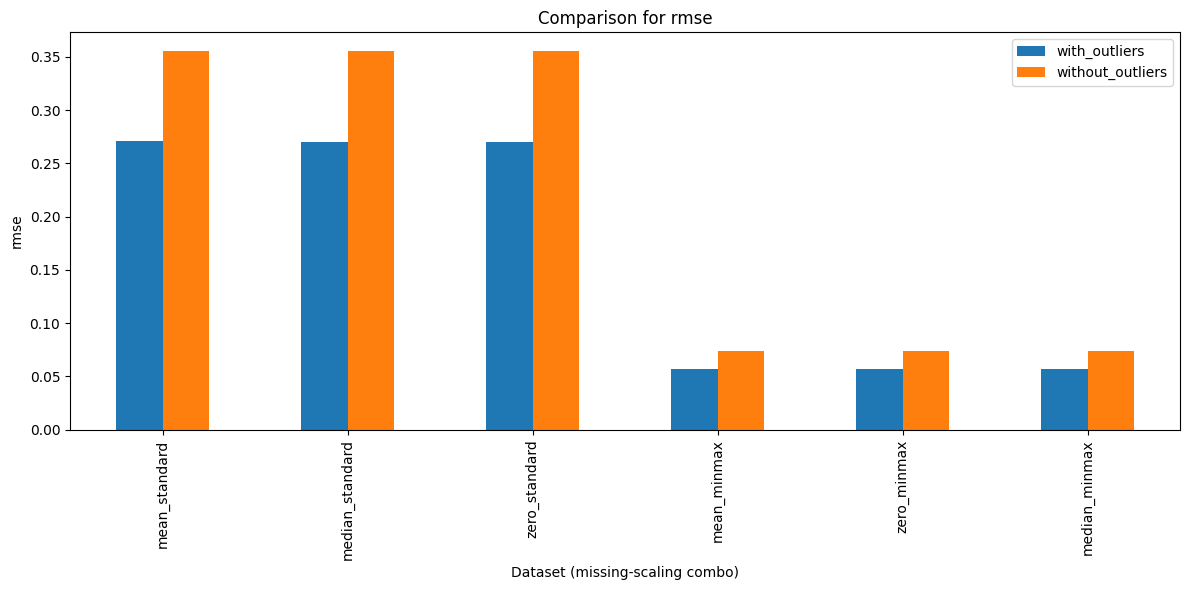

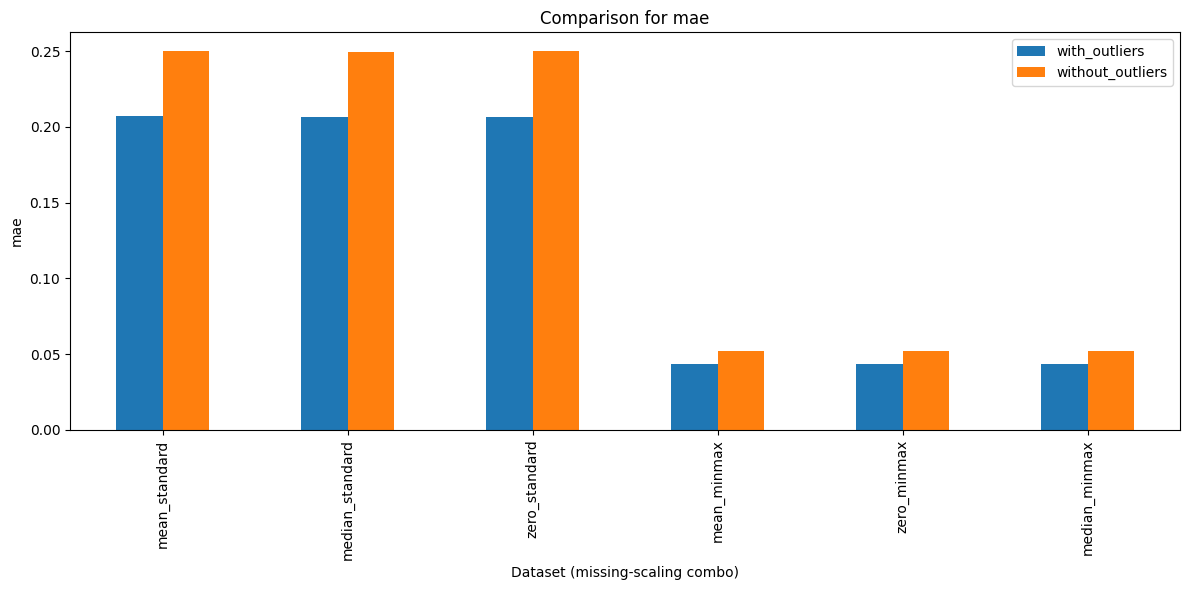

Done. Plots saved as *_comparison.png


In [ ]:
results_df = run_all(df_zero, df_mean, df_median)
results_df.to_csv("results_summary.csv", index=False)
print("Saved results_summary.csv")
print(results_df)

for metric in ["r2", "mse", "rmse", "mae"]:
    plot_metric(results_df, metric, title=f"Comparison for {metric}", savepath=f"{metric}_comparison.png")

print("Done. Plots saved as *_comparison.png")